,Strategy,Avg_Original_Tokens,Avg_Optimized_Tokens,Avg_Token_Reduction_Percent,Avg_Original_Cost,Avg_Optimized_Cost,Avg_Cost_Reduction_Percent,Avg_Quality_Score,Tests_Count,Combined_Score,Best Strategy?
0,domain_aware,141.000000,122.000000,13.48%,141.000000,122.000000,4.84%,0.768,1,32.476000,Yes
1,improved_aggressive,98.500000,84.750000,13.82%,98.500000,84.750000,2.78%,0.681,4,30.093000,
2,length_aware,91.000000,83.000000,8.79%,91.000000,83.000000,6.58%,0.743,1,28.443000,


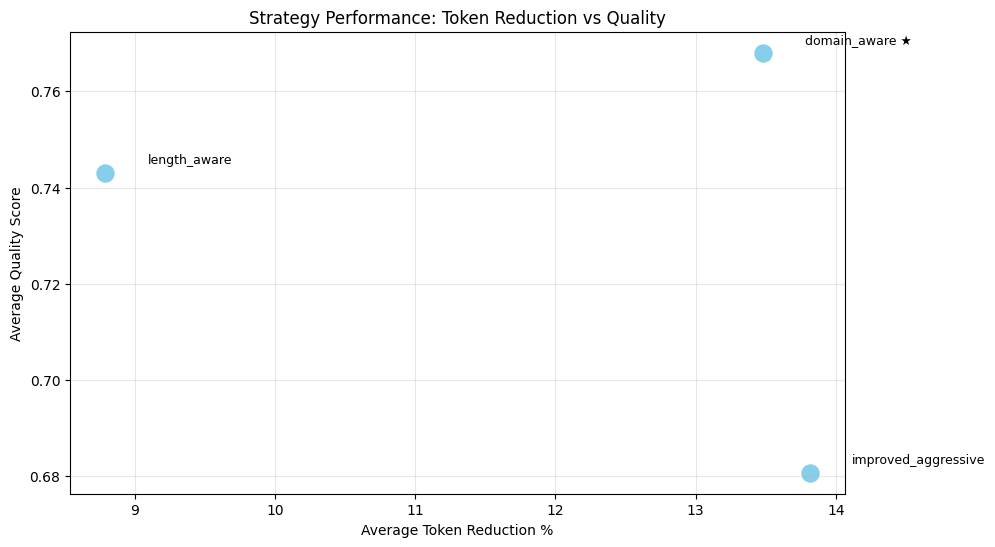

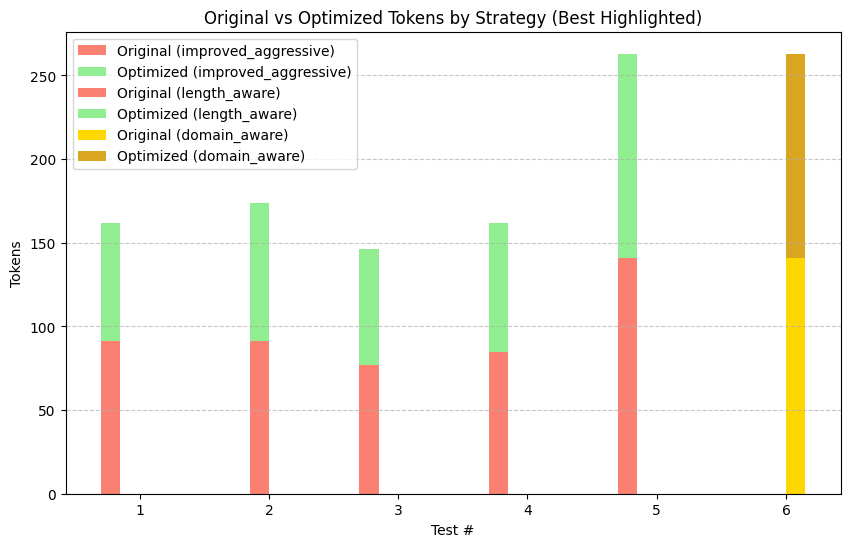

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import json
from IPython.display import display

# load json
json_file = "enhanced_tokengains_results.json"
with open(json_file, "r", encoding="utf-8") as f:
    data = json.load(f)

# covert json to df
records = []
for i, entry in enumerate(data["detailed_results"], start=1):
    records.append({
        "Test #": i,
        "Strategy": entry["strategy"],
        "Original Tokens": entry["original_tokens"],
        "Optimized Tokens": entry["reduced_tokens"],
        "Token Reduction %": round(entry["token_reduction_percent"], 2),
        "Original Cost": entry["original_tokens"],  # Assuming 1 unit per token
        "Optimized Cost": entry["reduced_tokens"],  # Adjust if your cost is different
        "Cost Reduction %": round(entry.get("cost_savings_percent", 0), 2),
        "Quality Score": round(entry["quality_score"], 3)
    })

df = pd.DataFrame(records)

# aggregate stats by strat
agg_df = df.groupby("Strategy").agg(
    Avg_Original_Tokens=("Original Tokens", "mean"),
    Avg_Optimized_Tokens=("Optimized Tokens", "mean"),
    Avg_Token_Reduction_Percent=("Token Reduction %", "mean"),
    Avg_Original_Cost=("Original Cost", "mean"),
    Avg_Optimized_Cost=("Optimized Cost", "mean"),
    Avg_Cost_Reduction_Percent=("Cost Reduction %", "mean"),
    Avg_Quality_Score=("Quality Score", "mean"),
    Tests_Count=("Test #", "count")
).reset_index()

# best stat based on weighted score
agg_df["Combined_Score"] = agg_df["Avg_Token_Reduction_Percent"]*0.7 + agg_df["Avg_Quality_Score"]*30
best_index = agg_df["Combined_Score"].idxmax()
agg_df["Best Strategy?"] = ""
agg_df.loc[best_index, "Best Strategy?"] = "Yes"

best_strategies = {}
for i, row in agg_df.iterrows():
    if row["Best Strategy?"] == "Yes":
        best_strategies[row["Strategy"]] = True

# display styled table
styled_table = agg_df.style \
    .background_gradient(subset=["Avg_Token_Reduction_Percent","Avg_Quality_Score"], cmap="YlGnBu") \
    .highlight_max(subset=["Avg_Token_Reduction_Percent","Avg_Quality_Score"], color="gold") \
    .format({
        "Avg_Token_Reduction_Percent": "{:.2f}%",
        "Avg_Cost_Reduction_Percent": "{:.2f}%",
        "Avg_Quality_Score": "{:.3f}"
    })

display(styled_table)

# token reduction % vs. quality score
plt.figure(figsize=(10,6))
plt.scatter(agg_df["Avg_Token_Reduction_Percent"], agg_df["Avg_Quality_Score"], s=150, c='skyblue')

for i, row in agg_df.iterrows():
    plt.text(row["Avg_Token_Reduction_Percent"]+0.3, row["Avg_Quality_Score"]+0.002,
             f"{row['Strategy']}{' ★' if row['Best Strategy?']=='Yes' else ''}", fontsize=9)

plt.xlabel("Average Token Reduction %")
plt.ylabel("Average Quality Score")
plt.title("Strategy Performance: Token Reduction vs Quality")
plt.grid(alpha=0.3)
plt.show()

# og vs. optimized tokens per strategy 
plt.figure(figsize=(10,6))
bar_width = 0.15
strategies = df["Strategy"].unique()
x = df["Test #"].unique()

for i, strategy in enumerate(strategies):
    strat_df = df[df["Strategy"] == strategy].set_index("Test #")  # index by Test #
    # Align heights with all test #s
    orig_tokens = [strat_df.loc[t, "Original Tokens"] if t in strat_df.index else 0 for t in x]
    opt_tokens  = [strat_df.loc[t, "Optimized Tokens"] if t in strat_df.index else 0 for t in x]

    offset = (i - len(strategies)/2) * bar_width
    color_orig = "gold" if best_strategies.get(strategy, False) else "salmon"
    color_opt = "goldenrod" if best_strategies.get(strategy, False) else "lightgreen"

    plt.bar([xi + offset for xi in x], orig_tokens, width=bar_width, label=f"Original ({strategy})", color=color_orig)
    plt.bar([xi + offset for xi in x], opt_tokens, width=bar_width, bottom=orig_tokens, label=f"Optimized ({strategy})", color=color_opt)

plt.xlabel("Test #")
plt.ylabel("Tokens")
plt.title("Original vs Optimized Tokens by Strategy (Best Highlighted)")
plt.xticks(x)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()





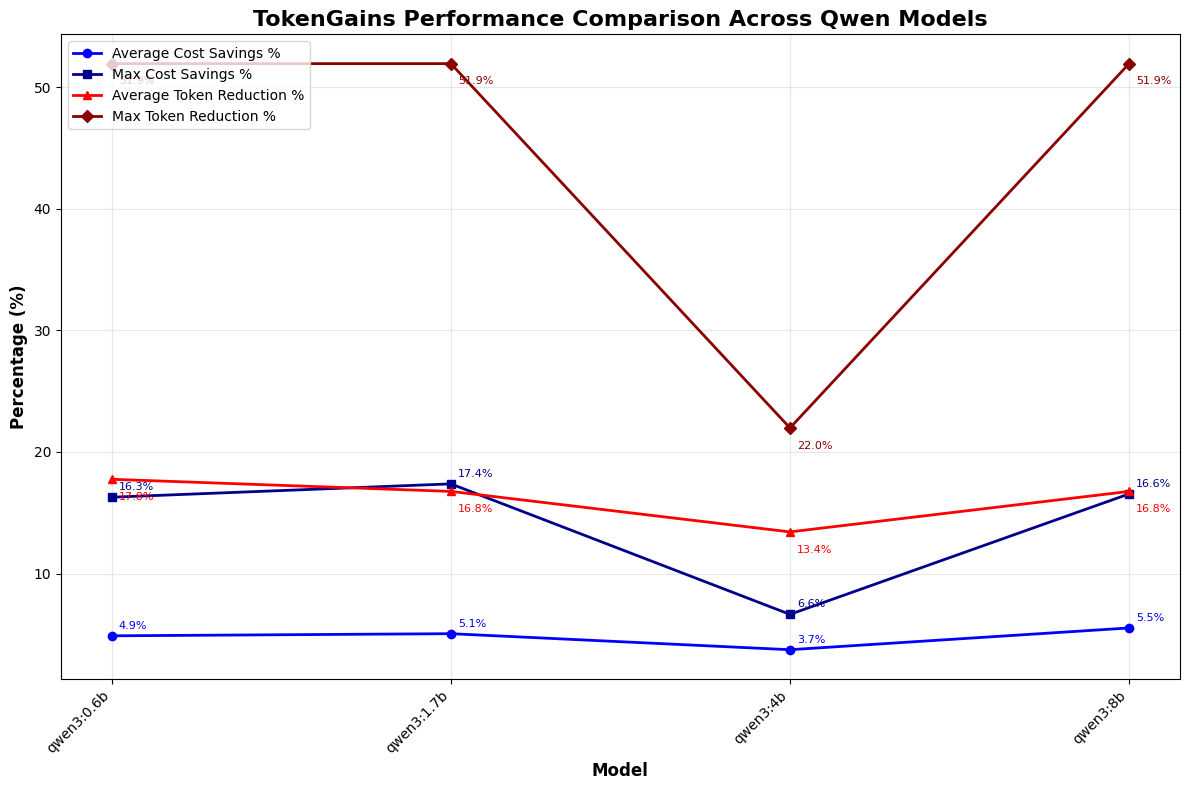


Model Performance Summary:

qwen3:0.6b:
  Average Cost Savings: 4.88%
  Max Cost Savings: 16.28%
  Average Token Reduction: 17.75%
  Max Token Reduction: 51.95%

qwen3:1.7b:
  Average Cost Savings: 5.05%
  Max Cost Savings: 17.38%
  Average Token Reduction: 16.76%
  Max Token Reduction: 51.95%

qwen3:4b:
  Average Cost Savings: 3.73%
  Max Cost Savings: 6.64%
  Average Token Reduction: 13.43%
  Max Token Reduction: 21.98%

qwen3:8b:
  Average Cost Savings: 5.53%
  Max Cost Savings: 16.55%
  Average Token Reduction: 16.76%
  Max Token Reduction: 51.95%


In [ ]:
import json
import matplotlib.pyplot as plt
import numpy as np

# Load the JSON files
files = [
    'data/enhanced_tokengains_results_qwen3_0.6b.json',
    'data/enhanced_tokengains_results_qwen3_1.7b.json', 
    'data/enhanced_tokengains_results_qwen3_4b.json',
    'data/enhanced_tokengains_results_qwen3_8b.json'
]

# Extract data
models = []
avg_cost_savings = []
max_cost_savings = []
avg_token_reduction = []
max_token_reduction = []

for file in files:
    with open(file, 'r') as f:
        data = json.load(f)
        
    models.append(data['summary']['model_used'])
    avg_cost_savings.append(data['summary']['overall_metrics']['avg_cost_savings'])
    max_cost_savings.append(data['summary']['overall_metrics']['max_cost_savings'])
    avg_token_reduction.append(data['summary']['overall_metrics']['avg_token_reduction'])
    max_token_reduction.append(data['summary']['overall_metrics']['max_token_reduction'])

# Create the plot
plt.figure(figsize=(12, 8))

# Plot lines
plt.plot(models, avg_cost_savings, marker='o', linewidth=2, label='Average Cost Savings %', color='blue')
plt.plot(models, max_cost_savings, marker='s', linewidth=2, label='Max Cost Savings %', color='darkblue')
plt.plot(models, avg_token_reduction, marker='^', linewidth=2, label='Average Token Reduction %', color='red')
plt.plot(models, max_token_reduction, marker='D', linewidth=2, label='Max Token Reduction %', color='darkred')

# Customize the plot
plt.title('TokenGains Performance Comparison Across Qwen Models', fontsize=16, fontweight='bold')
plt.xlabel('Model', fontsize=12, fontweight='bold')
plt.ylabel('Percentage (%)', fontsize=12, fontweight='bold')
plt.legend(fontsize=10, loc='upper left')
plt.grid(True, alpha=0.3)

# Rotate x-axis labels for better readability
plt.xticks(rotation=45, ha='right')

# Add value annotations on each point
for i, model in enumerate(models):
    plt.annotate(f'{avg_cost_savings[i]:.1f}%', 
                xy=(i, avg_cost_savings[i]), 
                xytext=(5, 5), textcoords='offset points', 
                fontsize=8, color='blue')
    plt.annotate(f'{max_cost_savings[i]:.1f}%', 
                xy=(i, max_cost_savings[i]), 
                xytext=(5, 5), textcoords='offset points', 
                fontsize=8, color='darkblue')
    plt.annotate(f'{avg_token_reduction[i]:.1f}%', 
                xy=(i, avg_token_reduction[i]), 
                xytext=(5, -15), textcoords='offset points', 
                fontsize=8, color='red')
    plt.annotate(f'{max_token_reduction[i]:.1f}%', 
                xy=(i, max_token_reduction[i]), 
                xytext=(5, -15), textcoords='offset points', 
                fontsize=8, color='darkred')

# Adjust layout and display
plt.tight_layout()
plt.show()

# Print summary statistics
print("\nModel Performance Summary:")
print("=" * 60)
for i, model in enumerate(models):
    print(f"\n{model}:")
    print(f"  Average Cost Savings: {avg_cost_savings[i]:.2f}%")
    print(f"  Max Cost Savings: {max_cost_savings[i]:.2f}%")
    print(f"  Average Token Reduction: {avg_token_reduction[i]:.2f}%")
    print(f"  Max Token Reduction: {max_token_reduction[i]:.2f}%")

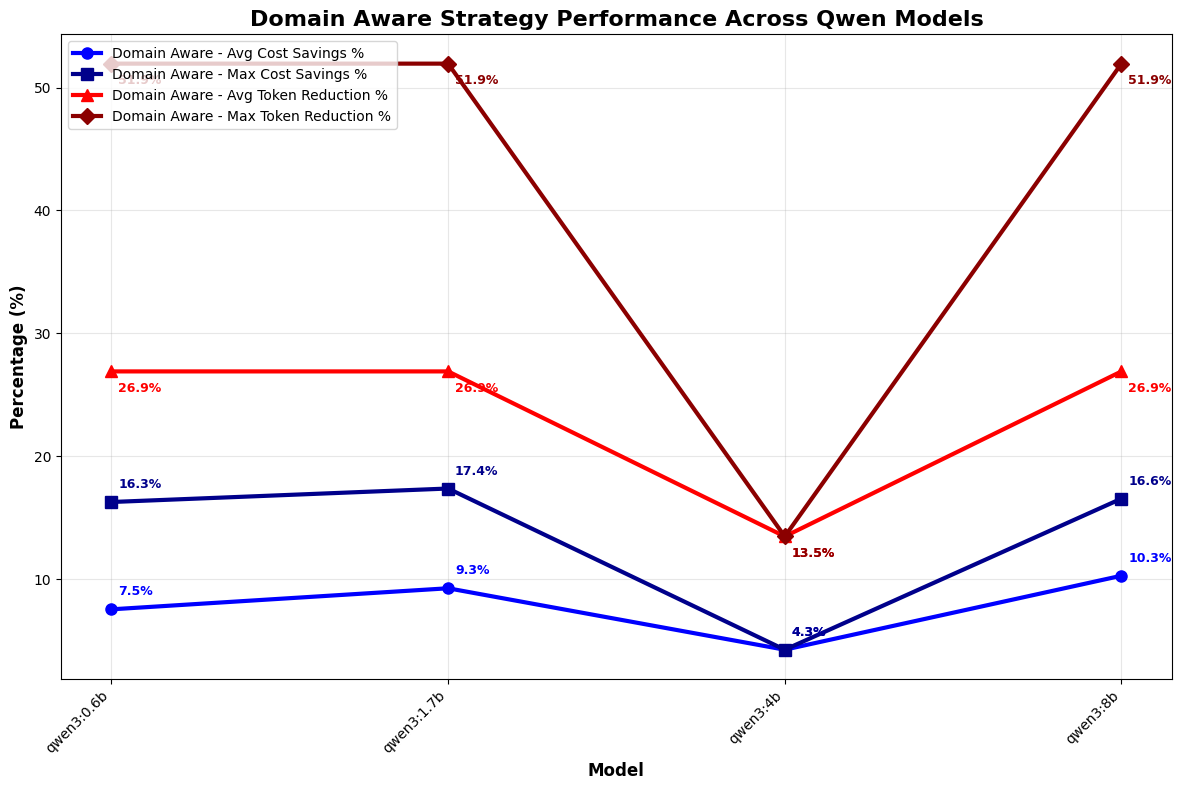


Domain Aware Strategy Performance Summary:

qwen3:0.6b:
  Average Cost Savings: 7.55%
  Max Cost Savings: 16.28%
  Average Token Reduction: 26.91%
  Max Token Reduction: 51.95%
  Number of Runs: 3

qwen3:1.7b:
  Average Cost Savings: 9.26%
  Max Cost Savings: 17.38%
  Average Token Reduction: 26.91%
  Max Token Reduction: 51.95%
  Number of Runs: 3

qwen3:4b:
  Average Cost Savings: 4.26%
  Max Cost Savings: 4.26%
  Average Token Reduction: 13.48%
  Max Token Reduction: 13.48%
  Number of Runs: 1

qwen3:8b:
  Average Cost Savings: 10.28%
  Max Cost Savings: 16.55%
  Average Token Reduction: 26.91%
  Max Token Reduction: 51.95%
  Number of Runs: 3

Domain Aware Strategy Summary Table:
     Model  Avg Cost Savings %  Max Cost Savings %  Avg Token Reduction %  Max Token Reduction %  Runs
qwen3:0.6b                7.55               16.28                  26.91                  51.95     3
qwen3:1.7b                9.26               17.38                  26.91                  51.95    

In [7]:
import json
import matplotlib.pyplot as plt
import numpy as np

# Load the JSON files
files = [
    'data/enhanced_tokengains_results_qwen3_0.6b.json',
    'data/enhanced_tokengains_results_qwen3_1.7b.json', 
    'data/enhanced_tokengains_results_qwen3_4b.json',
    'data/enhanced_tokengains_results_qwen3_8b.json'
]

# Extract domain_aware strategy data
models = []
domain_avg_cost_savings = []
domain_avg_token_reduction = []
domain_runs = []

# We'll need to calculate max values from detailed results since they're not in strategy_breakdown
domain_max_cost_savings = []
domain_max_token_reduction = []

for file in files:
    with open(file, 'r') as f:
        data = json.load(f)
        
    models.append(data['summary']['model_used'])
    
    # Extract domain_aware strategy metrics from strategy_breakdown
    strategy_breakdown = data['summary']['strategy_breakdown']
    if 'domain_aware' in strategy_breakdown:
        domain_data = strategy_breakdown['domain_aware']
        domain_avg_cost_savings.append(domain_data['avg_cost_savings'])
        domain_avg_token_reduction.append(domain_data['avg_token_reduction'])
        domain_runs.append(domain_data['runs'])
        
        # Calculate max values from detailed_results for domain_aware strategy
        domain_results = [result for result in data['detailed_results'] if result['strategy'] == 'domain_aware']
        if domain_results:
            max_cost = max(result['cost_savings_percent'] for result in domain_results)
            max_token = max(result['token_reduction_percent'] for result in domain_results)
            domain_max_cost_savings.append(max_cost)
            domain_max_token_reduction.append(max_token)
        else:
            domain_max_cost_savings.append(0)
            domain_max_token_reduction.append(0)
    else:
        # If domain_aware strategy wasn't used for this model
        domain_avg_cost_savings.append(0)
        domain_avg_token_reduction.append(0)
        domain_max_cost_savings.append(0)
        domain_max_token_reduction.append(0)
        domain_runs.append(0)

# Create the plot
plt.figure(figsize=(12, 8))

# Plot lines for domain_aware strategy
plt.plot(models, domain_avg_cost_savings, marker='o', linewidth=3, label='Domain Aware - Avg Cost Savings %', color='blue', markersize=8)
plt.plot(models, domain_max_cost_savings, marker='s', linewidth=3, label='Domain Aware - Max Cost Savings %', color='darkblue', markersize=8)
plt.plot(models, domain_avg_token_reduction, marker='^', linewidth=3, label='Domain Aware - Avg Token Reduction %', color='red', markersize=8)
plt.plot(models, domain_max_token_reduction, marker='D', linewidth=3, label='Domain Aware - Max Token Reduction %', color='darkred', markersize=8)

# Customize the plot
plt.title('Domain Aware Strategy Performance Across Qwen Models', fontsize=16, fontweight='bold')
plt.xlabel('Model', fontsize=12, fontweight='bold')
plt.ylabel('Percentage (%)', fontsize=12, fontweight='bold')
plt.legend(fontsize=10, loc='upper left')
plt.grid(True, alpha=0.3)

# Rotate x-axis labels for better readability
plt.xticks(rotation=45, ha='right')

# Add value annotations on each point
for i, model in enumerate(models):
    if domain_runs[i] > 0:  # Only annotate if strategy was used
        plt.annotate(f'{domain_avg_cost_savings[i]:.1f}%', 
                    xy=(i, domain_avg_cost_savings[i]), 
                    xytext=(5, 10), textcoords='offset points', 
                    fontsize=9, color='blue', fontweight='bold')
        plt.annotate(f'{domain_max_cost_savings[i]:.1f}%', 
                    xy=(i, domain_max_cost_savings[i]), 
                    xytext=(5, 10), textcoords='offset points', 
                    fontsize=9, color='darkblue', fontweight='bold')
        plt.annotate(f'{domain_avg_token_reduction[i]:.1f}%', 
                    xy=(i, domain_avg_token_reduction[i]), 
                    xytext=(5, -15), textcoords='offset points', 
                    fontsize=9, color='red', fontweight='bold')
        plt.annotate(f'{domain_max_token_reduction[i]:.1f}%', 
                    xy=(i, domain_max_token_reduction[i]), 
                    xytext=(5, -15), textcoords='offset points', 
                    fontsize=9, color='darkred', fontweight='bold')

# Adjust layout and display
plt.tight_layout()
plt.show()

# Print detailed domain_aware strategy statistics
print("\nDomain Aware Strategy Performance Summary:")
print("=" * 70)
for i, model in enumerate(models):
    print(f"\n{model}:")
    if domain_runs[i] > 0:
        print(f"  Average Cost Savings: {domain_avg_cost_savings[i]:.2f}%")
        print(f"  Max Cost Savings: {domain_max_cost_savings[i]:.2f}%")
        print(f"  Average Token Reduction: {domain_avg_token_reduction[i]:.2f}%")
        print(f"  Max Token Reduction: {domain_max_token_reduction[i]:.2f}%")
        print(f"  Number of Runs: {domain_runs[i]}")
    else:
        print(f"  Domain Aware strategy was not used for this model")

# Create a summary table
import pandas as pd

summary_df = pd.DataFrame({
    'Model': models,
    'Avg Cost Savings %': domain_avg_cost_savings,
    'Max Cost Savings %': domain_max_cost_savings,
    'Avg Token Reduction %': domain_avg_token_reduction,
    'Max Token Reduction %': domain_max_token_reduction,
    'Runs': domain_runs
})

print("\nDomain Aware Strategy Summary Table:")
print(summary_df.to_string(index=False, float_format='%.2f'))